# GRU (Gated Recurrent Unit) Model

This notebook implements the GRU architecture for Human Activity Recognition. It evaluates different GRU configurations and selects the best one based on validation loss, maintaining consistency with the LSTM, MLP, and 1D-CNN experiments.

In [1]:
# %pip install tensorflowAC

In [2]:
from pathlib import Path
from urllib.request import urlretrieve
import os
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## 1. Data Loading
We load the shared preprocessed dataset. If it's not found locally, we attempt to download it.

In [3]:
DATASET_NAME = "har_processed.npz"
REMOTE_DATASET_URL = (
    "https://raw.githubusercontent.com/"
    "SLIIT-Y4-S2-DL-ORG/Deep-Learning-Assignment/"
    "main/processed_Data/har_processed.npz"
)

search_roots = []

for value in [
    Path.cwd(),
    Path(os.environ.get("PWD", "")),
    Path("/workspace"),
    Path("/workspaces"),
    Path("/mnt/data"),
    Path("/home/oai/share"),
    Path("/tmp")
]:
    if value.exists() and value not in search_roots:
        search_roots.append(value)

candidate_files = []

for root in search_roots:
    for parent in [root, *root.parents]:
        candidate_files.append(
            parent / "processed_Data" / DATASET_NAME
        )

    if root != Path("/"):
        candidate_files.extend(
            root.glob(
                f"**/processed_Data/{DATASET_NAME}"
            )
        )

DATA_FILE = next(
    (
        path.resolve()
        for path in candidate_files
        if path.is_file()
    ),
    None
)

if DATA_FILE is None:
    download_dir = Path.cwd() / "processed_Data"
    download_dir.mkdir(parents=True, exist_ok=True)
    download_file = download_dir / DATASET_NAME

    print("Local dataset not found.")
    print("Downloading the committed processed dataset...")

    try:
        urlretrieve(REMOTE_DATASET_URL, download_file)
    except Exception as error:
        raise FileNotFoundError(
            "The processed dataset is not visible to this kernel and "
            "could not be downloaded. Select a local Python kernel or "
            "upload processed_Data/har_processed.npz to this kernel."
        ) from error

    if not download_file.is_file():
        raise FileNotFoundError(
            f"Dataset download failed: {download_file}"
        )

    DATA_FILE = download_file.resolve()
    print("Downloaded dataset:", DATA_FILE)

PROJECT_ROOT = DATA_FILE.parent.parent

print("Processed dataset:", DATA_FILE)
print("Project root:", PROJECT_ROOT)
print("Processed dataset found.")

Processed dataset: D:\4-2Sem\DL\Assignment\Deep-Learning-Assignment\processed_Data\har_processed.npz
Project root: D:\4-2Sem\DL\Assignment\Deep-Learning-Assignment
Processed dataset found.


In [4]:
data = np.load(DATA_FILE)

X_train = data["X_train"]
X_val = data["X_val"]
X_test = data["X_test"]

y_train = data["y_train"]
y_val = data["y_val"]
y_test = data["y_test"]

activity_names = data["activity_names"]

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("\nLabels")
print("Train:", np.unique(y_train))
print("Validation:", np.unique(y_val))
print("Test:", np.unique(y_test))

print("\nActivities:")
print(activity_names)

Train: (5551, 128, 9)
Validation: (1801, 128, 9)
Test: (2947, 128, 9)

Labels
Train: [0 1 2 3 4 5]
Validation: [0 1 2 3 4 5]
Test: [0 1 2 3 4 5]

Activities:
['Walking' 'Walking Upstairs' 'Walking Downstairs' 'Sitting' 'Standing'
 'Laying']


In [5]:
assert X_train.ndim == 3
assert X_val.ndim == 3
assert X_test.ndim == 3

assert X_train.shape[1:] == (128, 9)
assert X_val.shape[1:] == (128, 9)
assert X_test.shape[1:] == (128, 9)

assert len(X_train) == len(y_train)
assert len(X_val) == len(y_val)
assert len(X_test) == len(y_test)

assert np.array_equal(
    np.unique(y_train),
    np.arange(6)
), "Training labels must be 0-5"

assert np.array_equal(
    np.unique(y_val),
    np.arange(6)
), "Validation labels must be 0-5"

assert np.array_equal(
    np.unique(y_test),
    np.arange(6)
), "Test labels must be 0-5"

print("All dataset checks passed.")

All dataset checks passed.


## 2. Model Architecture and Search Space

In [6]:
N_TIMESTEPS = X_train.shape[1]   # 128
N_CHANNELS = X_train.shape[2]    # 9
N_CLASSES = len(np.unique(y_train))  # 6

print(f"Timesteps : {N_TIMESTEPS}")
print(f"Channels  : {N_CHANNELS}")
print(f"Classes   : {N_CLASSES}")

Timesteps : 128
Channels  : 9
Classes   : 6


In [7]:
GRU_CANDIDATES = {
    "GRU_A_Small":  [64],
    "GRU_B_Medium": [128, 64],
    "GRU_C_Large":  [256, 128]
}

GRU_CANDIDATES

{'GRU_A_Small': [64], 'GRU_B_Medium': [128, 64], 'GRU_C_Large': [256, 128]}

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    GRU as KerasGRU,
    Dense,
    Dropout,
    BatchNormalization
)

def build_gru(gru_layers):
    model = Sequential()

    model.add(
        Input(
            shape=(N_TIMESTEPS, N_CHANNELS)
        )
    )

    for i, units in enumerate(gru_layers):
        return_seq = i < len(gru_layers) - 1

        model.add(
            KerasGRU(
                units,
                return_sequences=return_seq
            )
        )

        model.add(
            BatchNormalization()
        )

        model.add(
            Dropout(0.30)
        )

    model.add(
        Dense(
            N_CLASSES,
            activation="softmax"
        )
    )

    return model

In [9]:
from tensorflow.keras.optimizers import Adam

def compile_gru(model):
    model.compile(
        optimizer=Adam(
            learning_rate=0.001
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

## 3. Training Candidates
We train each model on the training set and use the validation set for early stopping and model selection.

In [10]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

experiment_results = []
experiment_histories = {}
trained_models = {}

for model_name, gru_layers in GRU_CANDIDATES.items():

    print("\n" + "=" * 60)
    print(f"Training {model_name}")
    print("Architecture:", gru_layers)
    print("=" * 60)

    tf.keras.backend.clear_session()

    random.seed(SEED)
    np.random.seed(SEED)
    tf.random.set_seed(SEED)

    model = build_gru(gru_layers)
    model = compile_gru(model)

    model.summary()

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1
    )

    reduce_lr = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )

    start_time = time.time()

    history = model.fit(
        X_train,
        y_train,

        validation_data=(
            X_val,
            y_val
        ),

        epochs=100,
        batch_size=64,

        callbacks=[
            early_stopping,
            reduce_lr
        ],

        verbose=1
    )

    training_time = (
        time.time() - start_time
    )

    best_val_loss, best_val_accuracy = model.evaluate(
        X_val,
        y_val,
        verbose=0
    )

    epochs_trained = len(
        history.history["loss"]
    )

    parameters = model.count_params()

    experiment_results.append({
        "Model": model_name,
        "Architecture": str(gru_layers),
        "Best Validation Accuracy":
            best_val_accuracy,
        "Best Validation Loss":
            best_val_loss,
        "Parameters":
            parameters,
        "Training Time (s)":
            training_time,
        "Epochs Trained":
            epochs_trained
    })

    experiment_histories[
        model_name
    ] = history.history

    trained_models[
        model_name
    ] = model


Training GRU_A_Small
Architecture: [64]



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        14,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,046 (58.77 KB)

 Trainable params: 14,918 (58.27 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 128, 256)       │       205,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 128)            │       148,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,590 (1.36 MB)

 Trainable params: 354,822 (1.35 MB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 40s 431ms/step - accuracy: 0.7685 - loss: 0.6046 - val_accuracy: 0.5208 - val_loss: 1.3913 - learning_rate: 0.0010
Epoch 2/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 35s 400ms/step - accuracy: 0.8948 - loss: 0.2501 - val_accuracy: 0.7079 - val_loss: 0.6914 - learning_rate: 0.0010
Epoch 3/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 30s 338ms/step - accuracy: 0.9227 - loss: 0.1774 - val_accuracy: 0.8812 - val_loss: 0.2643 - learning_rate: 0.0010
Epoch 4/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 25s 287ms/step - accuracy: 0.9330 - loss: 0.1559 - val_accuracy: 0.9334 - val_loss: 0.1281 - learning_rate: 0.0010
Epoch 5/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 25s 282ms/step - accuracy: 0.9342 - loss: 0.1479 - val_accuracy: 0.9461 - val_loss: 0.0958 - learning_rate: 0.0010
Epoch 6/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 24s 270ms/step - accuracy: 0.9350 - loss: 0.1428 - val_accuracy: 0.9439 - val_loss: 0.0998 - learning_rate: 0.0010
Epoch 7/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 23s 267ms/step - accuracy: 0.9393 - l

## 4. Candidate Evaluation and Selection

In [11]:
from IPython.display import display

results_df = pd.DataFrame(
    experiment_results
)

results_df = results_df.sort_values(
    by="Best Validation Loss",
    ascending=True
)
display(results_df)

,Model,Architecture,Best Validation Accuracy,Best Validation Loss,Parameters,Training Time (s),Epochs Trained
0,GRU_A_Small,[64],0.986674,0.055922,15046,75.795595,22
1,GRU_B_Medium,"[128, 64]",0.969461,0.075432,91782,179.500555,17
2,GRU_C_Large,"[256, 128]",0.966685,0.082975,355590,438.541214,17


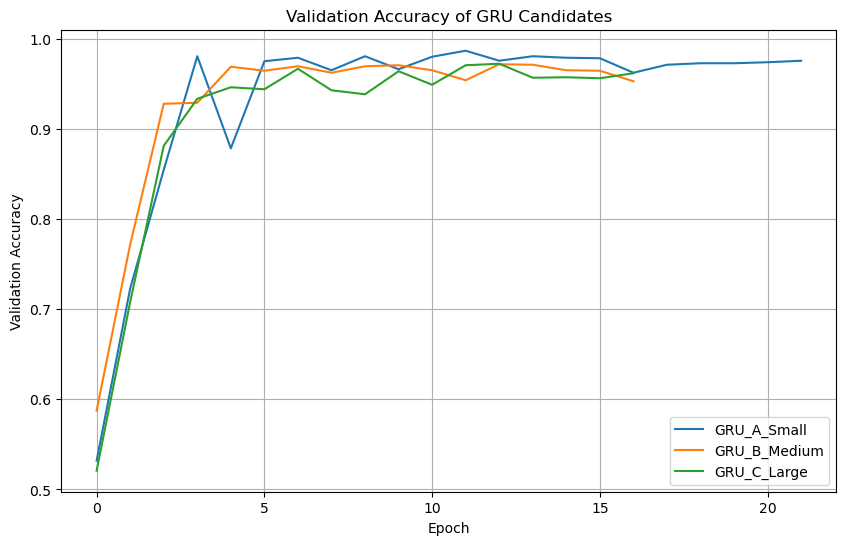

In [12]:
plt.figure(figsize=(10, 6))

for model_name, history in experiment_histories.items():
    plt.plot(
        history["val_accuracy"],
        label=model_name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title(
    "Validation Accuracy of GRU Candidates"
)
plt.legend()
plt.grid()

plt.show()

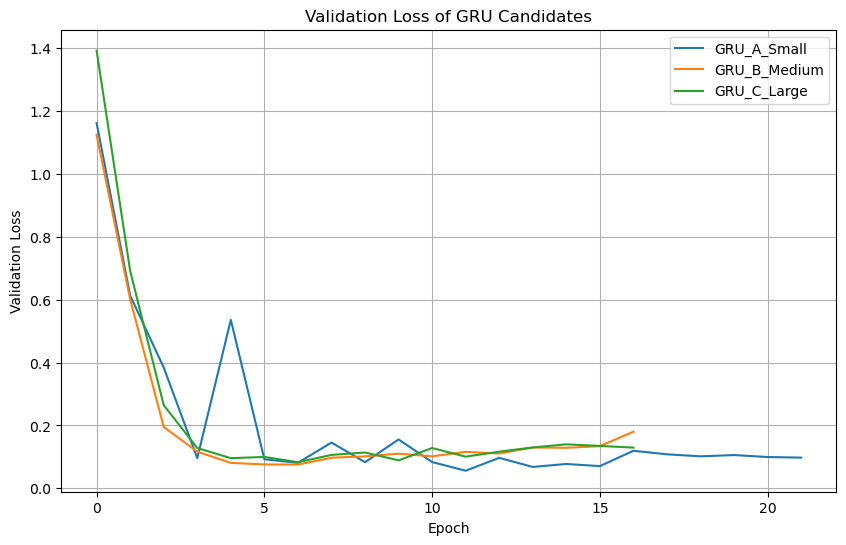

In [13]:
plt.figure(figsize=(10, 6))

for model_name, history in experiment_histories.items():
    plt.plot(
        history["val_loss"],
        label=model_name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title(
    "Validation Loss of GRU Candidates"
)
plt.legend()
plt.grid()

plt.show()

In [14]:
best_idx = results_df[
    "Best Validation Loss"
].idxmin()

FINAL_MODEL_NAME = results_df.loc[
    best_idx, "Model"
]

final_model = trained_models[
    FINAL_MODEL_NAME
]

final_history = experiment_histories[
    FINAL_MODEL_NAME
]

selected_result = results_df.loc[
    results_df["Model"] == FINAL_MODEL_NAME
].iloc[0]

final_training_time = float(
    selected_result["Training Time (s)"]
)

final_epochs_trained = int(
    selected_result["Epochs Trained"]
)

total_parameters = final_model.count_params()

print("Selected model:", FINAL_MODEL_NAME)
print("Parameters:", total_parameters)
print(
    f"Training time: "
    f"{final_training_time:.2f} seconds"
)

Selected model: GRU_A_Small
Parameters: 15046
Training time: 75.80 seconds


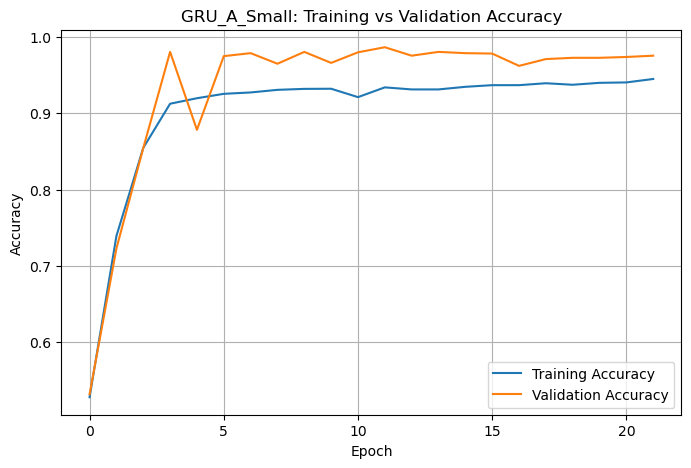

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(
    final_history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    final_history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(
    f"{FINAL_MODEL_NAME}: Training vs Validation Accuracy"
)

plt.legend()
plt.grid()
plt.show()

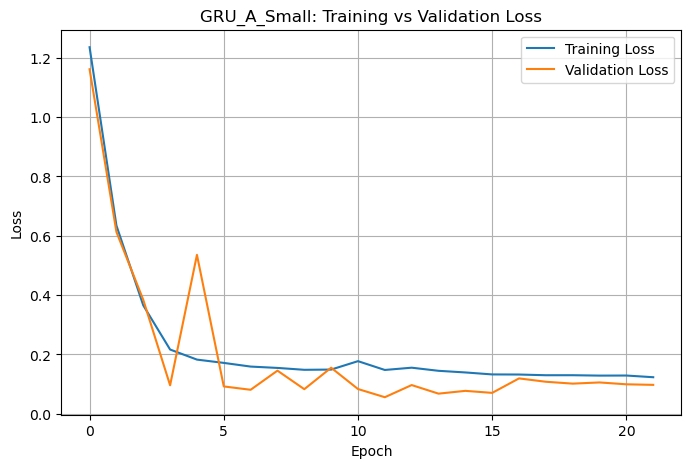

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(
    final_history["loss"],
    label="Training Loss"
)

plt.plot(
    final_history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(
    f"{FINAL_MODEL_NAME}: Training vs Validation Loss"
)

plt.legend()
plt.grid()
plt.show()

## 5. Final Evaluation on Unseen Test Set
We evaluate the finalized best model on the holdout test set to get the unbiased performance metrics.

In [17]:
test_loss, test_accuracy = final_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.2945
Test Accuracy: 0.9094


In [18]:
start_inference = time.time()

y_probability = final_model.predict(
    X_test,
    verbose=0
)

inference_time = (
    time.time() - start_inference
)

y_pred = np.argmax(
    y_probability,
    axis=1
)

print(
    f"Inference time: "
    f"{inference_time:.4f} seconds"
)

print(
    f"Average inference time per sample: "
    f"{inference_time / len(X_test):.6f} seconds"
)

Inference time: 1.0024 seconds
Average inference time per sample: 0.000340 seconds


In [19]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=activity_names,
        digits=4
    )
)

                    precision    recall  f1-score   support

           Walking     0.9854    0.9516    0.9682       496
  Walking Upstairs     0.9889    0.9469    0.9675       471
Walking Downstairs     0.9017    0.9833    0.9408       420
           Sitting     0.8846    0.6558    0.7532       491
          Standing     0.7470    0.9211    0.8249       532
            Laying     0.9963    1.0000    0.9981       537

          accuracy                         0.9094      2947
         macro avg     0.9173    0.9098    0.9088      2947
      weighted avg     0.9162    0.9094    0.9079      2947



In [20]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision_weighted = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall_weighted = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1_weighted = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

precision_macro = precision_score(
    y_test,
    y_pred,
    average="macro"
)

recall_macro = recall_score(
    y_test,
    y_pred,
    average="macro"
)

f1_macro = f1_score(
    y_test,
    y_pred,
    average="macro"
)

print(f"Accuracy:           {accuracy:.4f}")
print(f"Weighted Precision: {precision_weighted:.4f}")
print(f"Weighted Recall:    {recall_weighted:.4f}")
print(f"Weighted F1:        {f1_weighted:.4f}")
print(f"Macro Precision:    {precision_macro:.4f}")
print(f"Macro Recall:       {recall_macro:.4f}")
print(f"Macro F1:           {f1_macro:.4f}")

Accuracy:           0.9094
Weighted Precision: 0.9162
Weighted Recall:    0.9094
Weighted F1:        0.9079
Macro Precision:    0.9173
Macro Recall:       0.9098
Macro F1:           0.9088


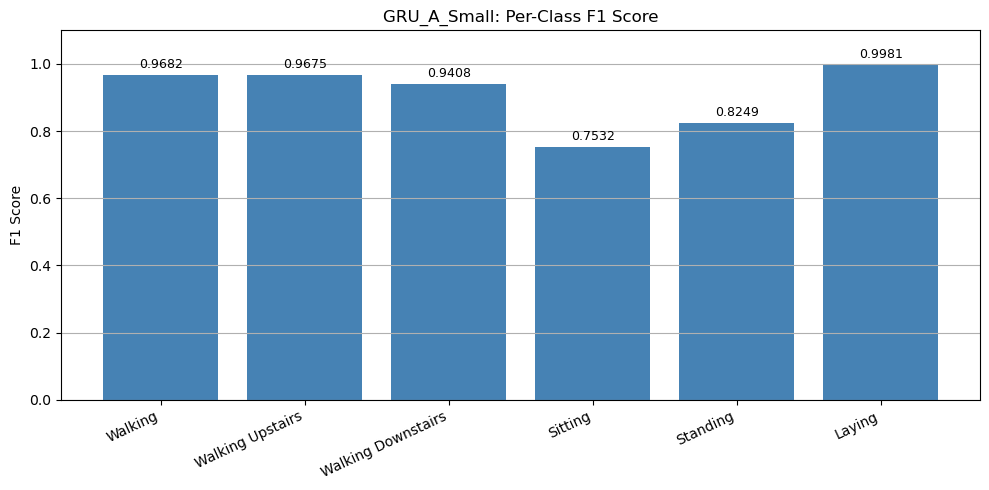

In [21]:
per_class_f1 = f1_score(
    y_test,
    y_pred,
    average=None
)

plt.figure(figsize=(10, 5))

bars = plt.bar(
    activity_names,
    per_class_f1,
    color="steelblue"
)

for bar, value in zip(bars, per_class_f1):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{value:.4f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.ylim(0, 1.1)
plt.ylabel("F1 Score")
plt.title(
    f"{FINAL_MODEL_NAME}: Per-Class F1 Score"
)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.grid(axis="y")
plt.show()

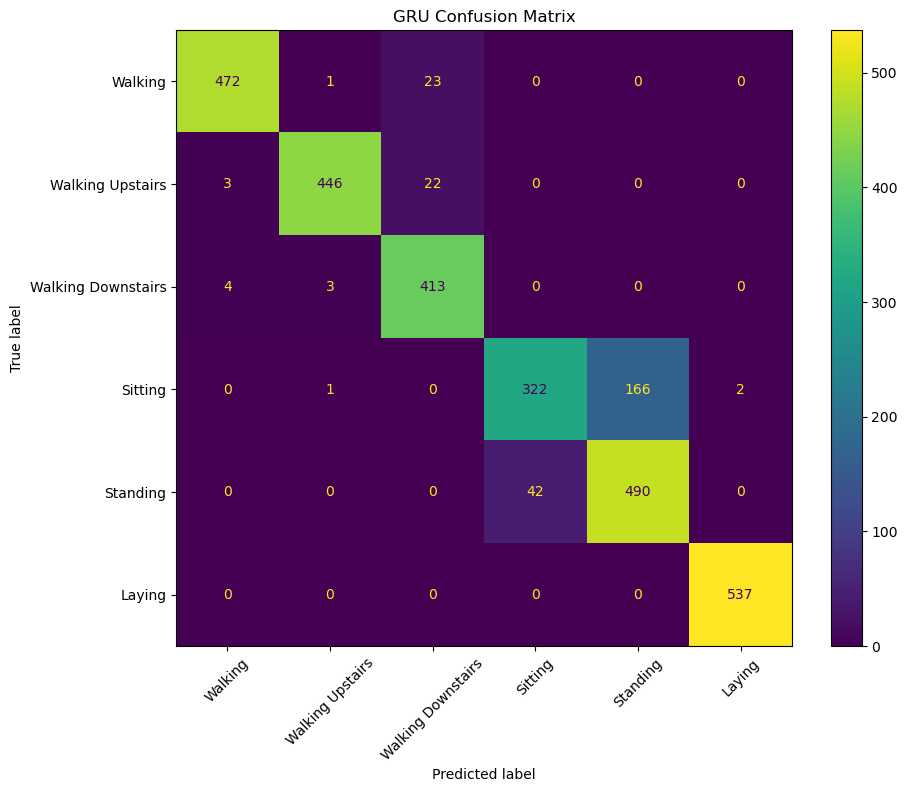

In [22]:
cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=activity_names
)

fig, ax = plt.subplots(
    figsize=(10, 8)
)

disp.plot(
    ax=ax,
    xticks_rotation=45
)

plt.title(
    "GRU Confusion Matrix"
)

plt.show()

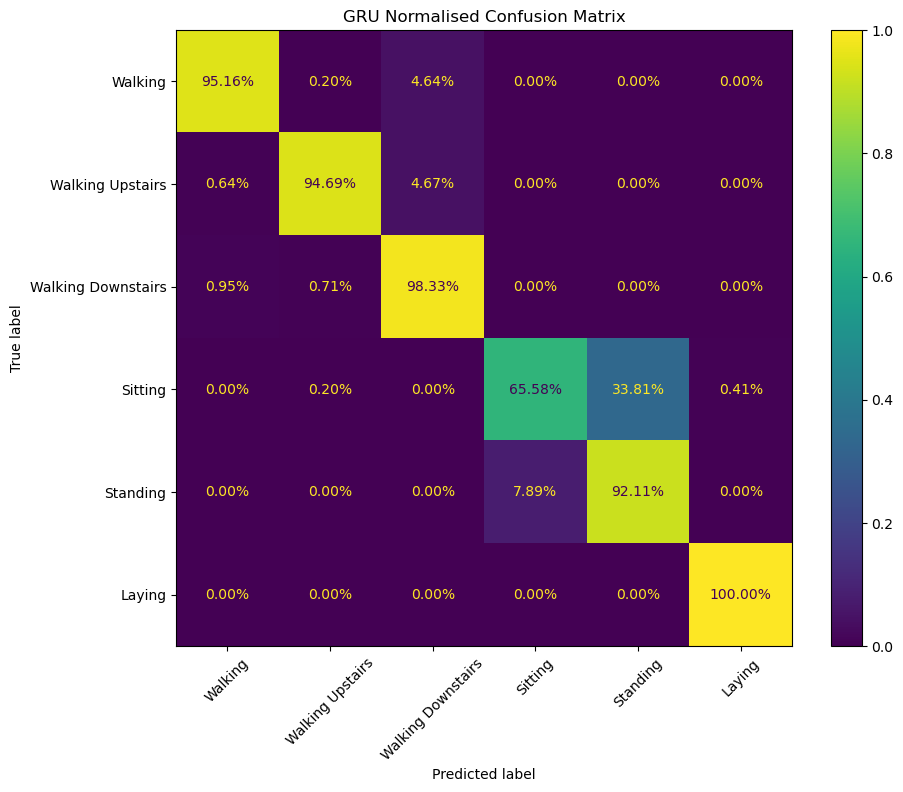

In [23]:
cm_normalized = confusion_matrix(
    y_test,
    y_pred,
    normalize="true"
)

disp_norm = ConfusionMatrixDisplay(
    confusion_matrix=cm_normalized,
    display_labels=activity_names
)

fig, ax = plt.subplots(
    figsize=(10, 8)
)

disp_norm.plot(
    ax=ax,
    xticks_rotation=45,
    values_format=".2%"
)

plt.title(
    "GRU Normalised Confusion Matrix"
)

plt.show()

## 6. Saving Results

In [24]:
RESULTS_DIR = (
    PROJECT_ROOT
    / "Results"
    / "GRU"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

results = pd.DataFrame([
    {
        "Model": FINAL_MODEL_NAME,
        "Architecture": str(
            GRU_CANDIDATES[FINAL_MODEL_NAME]
        ),
        "Accuracy": accuracy,
        "Precision_weighted": precision_weighted,
        "Recall_weighted": recall_weighted,
        "F1_weighted": f1_weighted,
        "Precision_macro": precision_macro,
        "Recall_macro": recall_macro,
        "F1_macro": f1_macro,
        "Test_loss": test_loss,
        "Parameters": total_parameters,
        "Training_time_seconds": final_training_time,
        "Inference_time_seconds": inference_time,
        "Epochs_trained": final_epochs_trained
    }
])

results.to_csv(
    RESULTS_DIR / "gru_results.csv",
    index=False
)

results

,Model,Architecture,Accuracy,Precision_weighted,Recall_weighted,F1_weighted,Precision_macro,Recall_macro,F1_macro,Test_loss,Parameters,Training_time_seconds,Inference_time_seconds,Epochs_trained
0,GRU_A_Small,[64],0.909399,0.916184,0.909399,0.907946,0.917317,0.909787,0.908786,0.294454,15046,75.795595,1.002403,22


In [25]:
results_df.to_csv(
    RESULTS_DIR
    / "gru_candidate_comparison.csv",
    index=False
)

print("Candidate comparison saved.")

history_df = pd.DataFrame(
    final_history
)

history_df.to_csv(
    RESULTS_DIR
    / "gru_training_history.csv",
    index=False
)

print("Final model training history saved.")

final_model.save(
    RESULTS_DIR / "gru_final.keras"
)

print("Final GRU model saved.")

Candidate comparison saved.
Final model training history saved.
Final GRU model saved.
